In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
image = cv2.imread('horse.jpg')

In [5]:
def normalize_image(image):
    min_max = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    z_score = np.zeros_like(image, dtype=np.float32)

    for i in range(3):
        channel = image[:,:,i]
        mean = np.mean(channel)
        std = np.std(channel)
        z_score[:,:,i] = (channel-mean)/(std+1e-8)

    z_score = cv2.normalize(z_score, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist_eq = cv2.equalizeHist(gray)

    return min_max, z_score, hist_eq

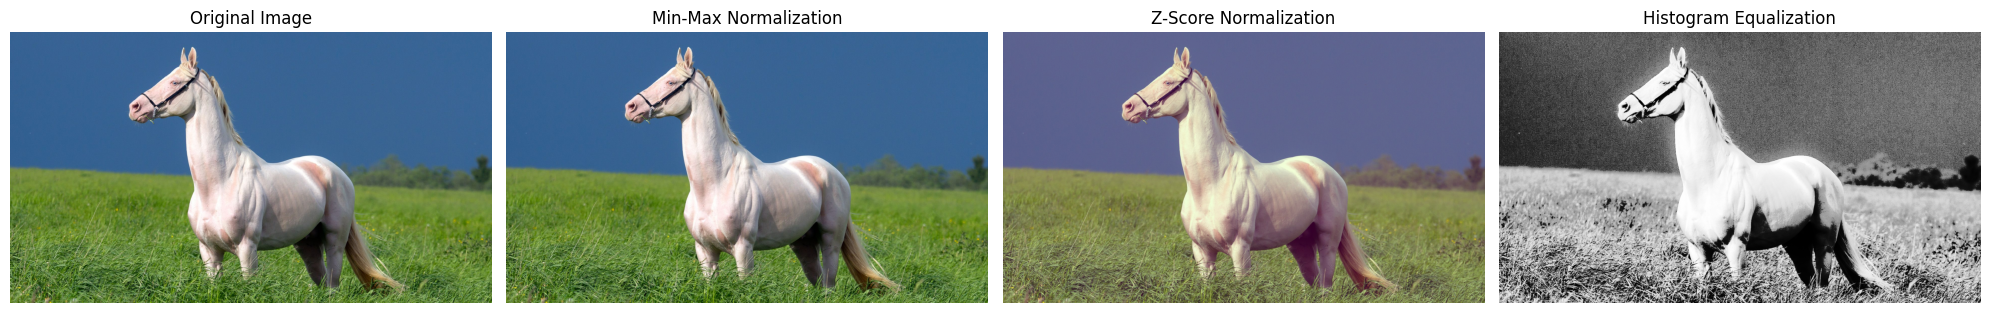

In [9]:
if image is None:
    print("Error: Image not found.")
else:
    min_max, z_score, hist_eq = normalize_image(image)

    plt.figure(figsize=(20,5))
    plt.subplot(141)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(142)
    plt.imshow(cv2.cvtColor(min_max, cv2.COLOR_BGR2RGB ))
    plt.title('Min-Max Normalization')
    plt.axis('off')

    plt.subplot(143)
    plt.imshow(cv2.cvtColor(z_score, cv2.COLOR_BGR2RGB))
    plt.title('Z-Score Normalization')
    plt.axis('off')

    plt.subplot(144)
    plt.imshow(hist_eq, cmap='gray')
    plt.title('Histogram Equalization')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
